Dataset Shape: (1800, 11)

First 5 rows of the dataset:

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB

Statistical Summary:

Missing Values in Each Column:
user_id                 0
day_type       

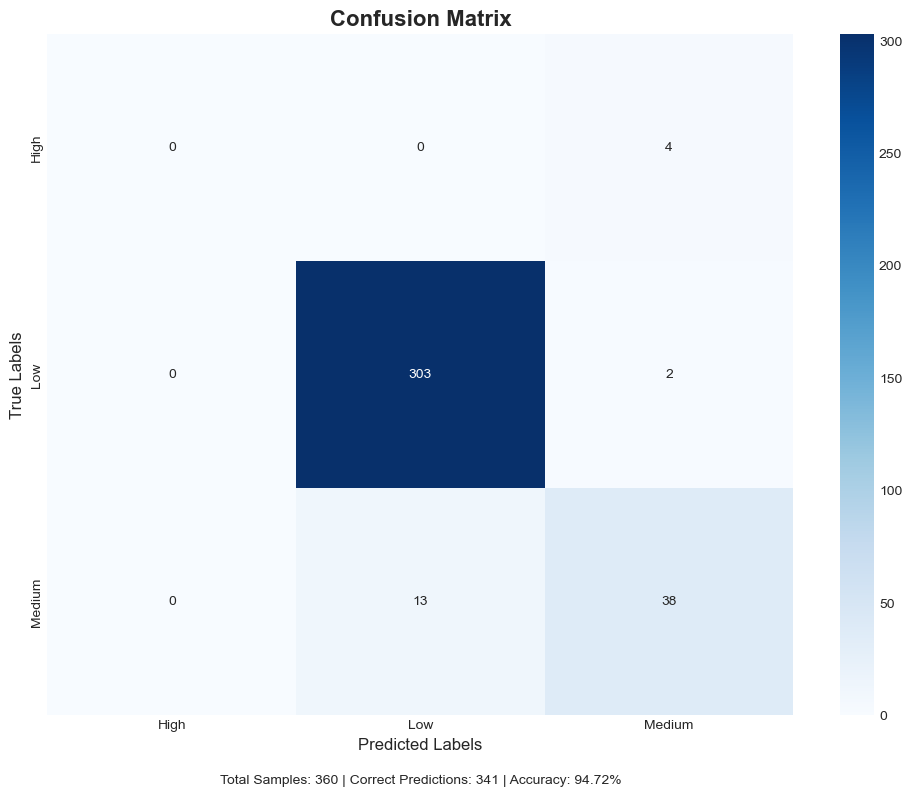


PER-CLASS PERFORMANCE METRICS

Class: High
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  Support:   4

Class: Low
  Precision: 0.9589
  Recall:    0.9934
  F1-Score:  0.9758
  Support:   305

Class: Medium
  Precision: 0.8636
  Recall:    0.7451
  F1-Score:  0.8000
  Support:   51


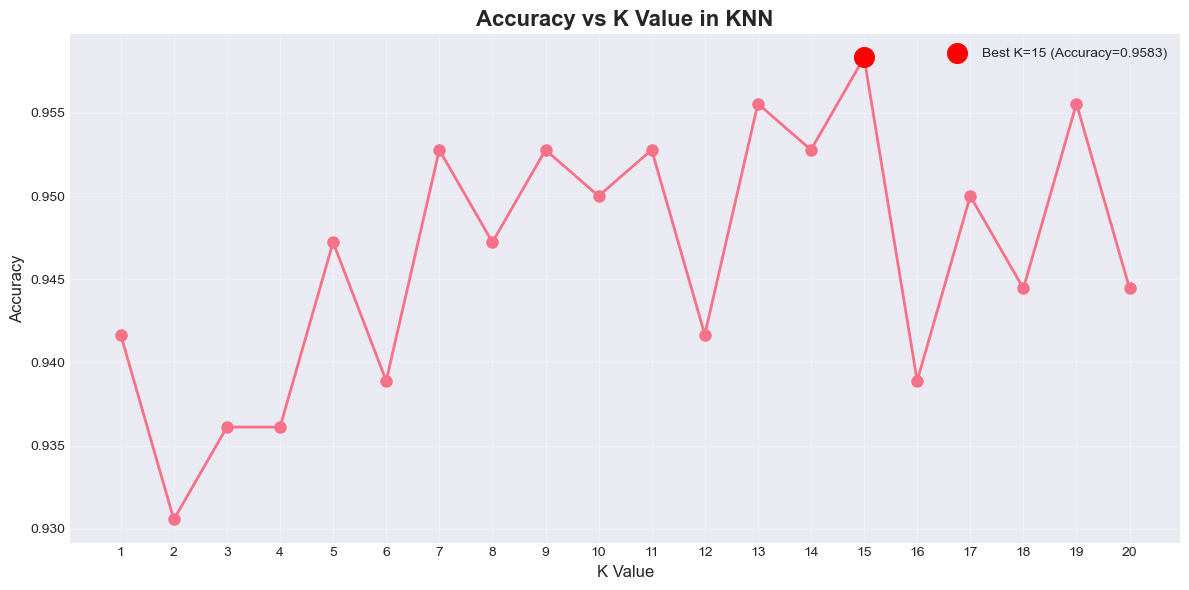


Best K value: 15 with accuracy: 0.9583

COMPARISON OF DISTANCE METRICS

EUCLIDEAN Distance:
  Accuracy: 0.9583
  Recall:   0.9583
  F1-Score: 0.9515

MANHATTAN Distance:
  Accuracy: 0.9556
  Recall:   0.9556
  F1-Score: 0.9484


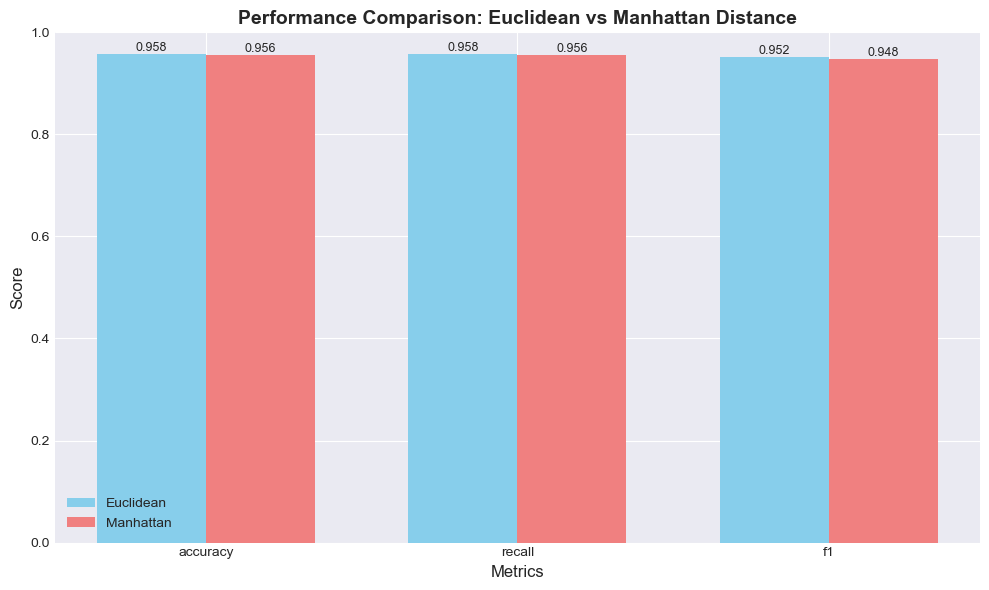


SUMMARY AND CONCLUSIONS

Dataset Information:
- Total samples: 1800
- Number of features: 10
- Number of classes: 3

Best Model Configuration:
- K value: 15
- Distance metric: Euclidean
- Training set size: 1440 samples
- Testing set size: 360 samples

Best Performance Metrics:
- Accuracy:  0.9472
- Recall:    0.7451
- F1 Score:  0.8000

Observations:
1. The KNN model was successfully implemented from scratch
2. Data preprocessing included handling missing values, encoding, and scaling
3. The model's performance is good
4. The optimal K value is 15
5. Euclidean distance performed better for this dataset



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


#2. Load and Explore the Dataset

df = pd.read_csv('work_from_home_burnout_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()

print("\nDataset Info:")
df.info()


# Statistical summary of numerical columns
print("\nStatistical Summary:")
df.describe()


# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


# 3. Data Preprocessing

# Remove duplicates if any
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")



numerical_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with mean
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"Filled missing values in {col} with mean")

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Filled missing values in {col} with mode")

print("\nMissing values after handling:")
print(df.isnull().sum())


# Identify the target column 
target_column = df.columns[-1]  # Last column as target
print(f"Target column: {target_column}")

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


# Encode categorical variables in features
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])
    print(f"Encoded column: {column}")


# Encode target variable if it's categorical
target_encoder = None
if y.dtype == 'object':
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y)
    print("Encoded target variable")
    print(f"Unique classes: {target_encoder.classes_}")


# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after scaling:")
X_scaled.head()

# 4. Split the Data

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting set class distribution:")
print(pd.Series(y_test).value_counts())


# 5. Implement KNN from Scratch


class KNNFromScratch:
    def __init__(self, k=3, distance_metric='euclidean'):
        """
        K-Nearest Neighbors implementation from scratch
        
        Parameters:
        k: number of neighbors to consider
        distance_metric: 'euclidean' or 'manhattan'
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """Store the training data"""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def _calculate_distance(self, x1, x2):
        """Calculate distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Distance metric not supported")
    
    def _predict_single(self, x):
        """Predict class for a single sample"""
        # Calculate distances to all training points
        distances = [self._calculate_distance(x, x_train) for x_train in self.X_train]
        
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get labels of k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Return the most common class label
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        return unique_labels[np.argmax(counts)]
    
    def predict(self, X):
        """Predict classes for multiple samples"""
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)
    
    def predict_proba(self, X):
        """Predict class probabilities for multiple samples"""
        X = np.array(X)
        probabilities = []
        
        for x in X:
            # Calculate distances to all training points
            distances = [self._calculate_distance(x, x_train) for x_train in self.X_train]
            
            # Get indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            
            # Get labels of k nearest neighbors
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            
            # Calculate probability for each class
            unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
            probs = counts / self.k
            
            # Create probability vector for all classes
            prob_vector = np.zeros(len(np.unique(self.y_train)))
            for label, prob in zip(unique_labels, probs):
                prob_vector[label] = prob
            
            probabilities.append(prob_vector)
        
        return np.array(probabilities)

# 6. Train and Evaluate KNN Model

# Initialize and train the KNN model
knn = KNNFromScratch(k=5, distance_metric='euclidean')
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

print("Predictions for first 10 test samples:")
print(y_pred[:10])
print("\nActual labels for first 10 test samples:")
print(y_test[:10])


# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)


# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


# 7. Visualize Confusion Matrix


# Plot confusion matrix
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y) if target_encoder is None else target_encoder.classes_,
            yticklabels=np.unique(y) if target_encoder is None else target_encoder.classes_)

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)

# Add text annotations
total_samples = np.sum(cm)
correct_predictions = np.trace(cm)
accuracy_percentage = (correct_predictions / total_samples) * 100

plt.text(0.5, -0.1, f'Total Samples: {total_samples} | Correct Predictions: {correct_predictions} | Accuracy: {accuracy_percentage:.2f}%',
         transform=plt.gca().transAxes, fontsize=10, ha='center')

plt.tight_layout()
plt.show()

# 8. Additional Analysis

# Calculate per-class metrics
if target_encoder is None:
    classes = np.unique(y)
else:
    classes = target_encoder.classes_

print("\n" + "="*50)
print("PER-CLASS PERFORMANCE METRICS")
print("="*50)

for i, class_name in enumerate(classes):
    # Calculate TP, FP, FN for this class
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    # Calculate metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nClass: {class_name}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Support:   {TP + FN}")

# 9. Find Optimal K Value

# Test different k values
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNNFromScratch(k=k, distance_metric='euclidean')
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

# Plot accuracy vs k
plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs K Value in KNN', fontsize=16, fontweight='bold')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

# Find best k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
plt.scatter(best_k, best_accuracy, color='red', s=200, zorder=5, 
            label=f'Best K={best_k} (Accuracy={best_accuracy:.4f})')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nBest K value: {best_k} with accuracy: {best_accuracy:.4f}")



# 10. Compare Different Distance Metrics


# Compare Euclidean vs Manhattan distance
distance_metrics = ['euclidean', 'manhattan']
results = {}

for metric in distance_metrics:
    knn_temp = KNNFromScratch(k=best_k, distance_metric=metric)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    
    results[metric] = {
        'accuracy': accuracy_score(y_test, y_pred_temp),
        'recall': recall_score(y_test, y_pred_temp, average='weighted'),
        'f1': f1_score(y_test, y_pred_temp, average='weighted')
    }

# Display results
print("\n" + "="*50)
print("COMPARISON OF DISTANCE METRICS")
print("="*50)
for metric, scores in results.items():
    print(f"\n{metric.upper()} Distance:")
    print(f"  Accuracy: {scores['accuracy']:.4f}")
    print(f"  Recall:   {scores['recall']:.4f}")
    print(f"  F1-Score: {scores['f1']:.4f}")


# Bar plot comparison
metrics_names = list(results['euclidean'].keys())
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [results['euclidean'][m] for m in metrics_names], width, label='Euclidean', color='skyblue')
bars2 = ax.bar(x + width/2, [results['manhattan'][m] for m in metrics_names], width, label='Manhattan', color='lightcoral')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: Euclidean vs Manhattan Distance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# 11. Summary and Conclusions

print("\n" + "="*60)
print("SUMMARY AND CONCLUSIONS")
print("="*60)
print(f"""
Dataset Information:
- Total samples: {len(df)}
- Number of features: {X.shape[1]}
- Number of classes: {len(np.unique(y))}

Best Model Configuration:
- K value: {best_k}
- Distance metric: Euclidean
- Training set size: {len(X_train)} samples
- Testing set size: {len(X_test)} samples

Best Performance Metrics:
- Accuracy:  {accuracy:.4f}
- Recall:    {recall:.4f}
- F1 Score:  {f1:.4f}

Observations:
1. The KNN model was successfully implemented from scratch
2. Data preprocessing included handling missing values, encoding, and scaling
3. The model's performance is {'good' if accuracy > 0.7 else 'moderate' if accuracy > 0.5 else 'poor'}
4. {f'The optimal K value is {best_k}'}
5. {'Euclidean' if results['euclidean']['accuracy'] > results['manhattan']['accuracy'] else 'Manhattan'} distance performed better for this dataset
""")